<a href="https://colab.research.google.com/github/Swag-Pseudopy/Escaping-Preference-Collapse/blob/main/lm_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install transformers torch numpy matplotlib

In [2]:
# Fix for AttributeError: module 'sympy' has no attribute 'core'
!pip install --upgrade sympy torch transformers
# Note: You may need to restart the runtime (Runtime > Restart runtime) after this completes.

GPT-2 Nash-MD Bifurcation Experiment  (Appendix G)

[1/3] Computing GPT-2 initial policy…
  Loading GPT-2-small (gpt2)…


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Raw log-probs: [ -69.7  -108.84 -190.2  -125.52 -236.34]
  Initial policy p0 : [1. 0. 0. 0. 0.]
  Initial entropy   : -0.000  (max = log 5 = 1.609)
  Initial C̃_0       : 130.098

[2/3] Running Nash-MD in three regimes…
  Expansive     τ=0.0000  τ/η=0.0 … final C̃=82.314  H=0.071
  Stable        τ=0.0550  τ/η=0.1 … final C̃=0.000  H=1.609
  Collapsing    τ=0.5000  τ/η=1.0 … final C̃=-0.000  H=1.609

  Theoretical C̃* (Regime 2, Regime 1 approx): 0.0000
  Note: exact C̃* solves the self-consistent eqn; this is the first iterate.

[3/3] Generating figure…
  Saved: Images/lm_bifurcation.pdf / .png


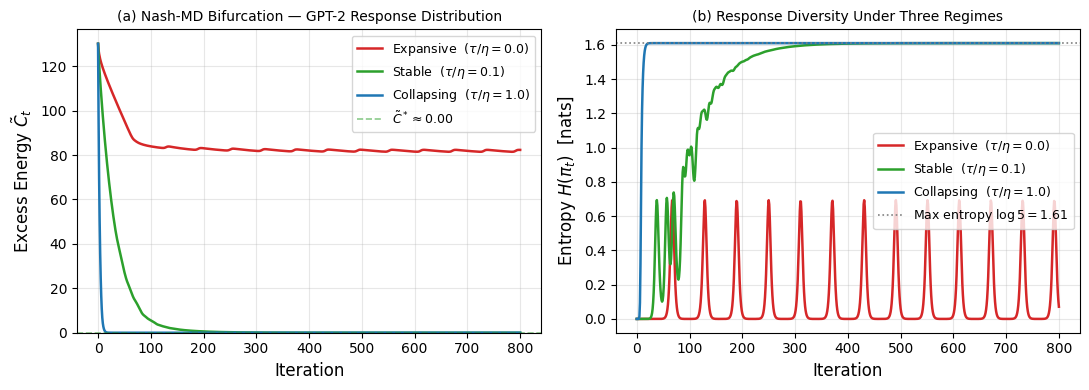


Summary
------------------------------------------------------
Regime          τ/η    Final C̃     Final H
------------------------------------------------------
Expansive       0.0     82.3142      0.0712
Stable          0.1      0.0000      1.6094
Collapsing      1.0     -0.0000      1.6094
------------------------------------------------------
                    Max entropy      1.6094

Interpretation:
  Expansive  : C̃ grows → policy concentrates → diversity lost
  Stable     : C̃ stabilises → controlled limit cycling → diversity maintained
  Collapsing : C̃ → 0 → policy → uniform Nash equilibrium


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# ── Configuration ─────────────────────────────────────────────────────────────
SEED    = 42
K       = 5          # number of response templates
N_ITER  = 800        # Nash-MD iterations
ETA     = 0.5       # learning rate  η
DEVICE  = "cpu"
OUT_DIR = "Images"   # where to save figures

torch.manual_seed(SEED)
np.random.seed(SEED)
os.makedirs(OUT_DIR, exist_ok=True)

# ── Prompt and response templates ─────────────────────────────────────────────
PROMPT = "Explain the concept of neural networks:"

# k=5 stylistically distinct responses that plausibly form a Condorcet cycle:
#  A concise  > B detailed  (saves time)
#  B detailed > C bulleted  (more nuanced)
#  C bulleted > D analogy   (easier scan)
#  D analogy  > E technical (more accessible)
#  E technical> A concise   (more precise)
RESPONSES = [
    # A – concise
    "Neural networks are computing systems inspired by biological neural networks "
    "that learn to perform tasks by being exposed to examples.",
    # B – detailed
    "Neural networks consist of layers of interconnected nodes that process information "
    "through weighted connections and non-linear activation functions, enabling them to "
    "approximate complex functions from data.",
    # C – bulleted
    ("Key components of neural networks:\n"
     "• Input layer: receives raw data\n"
     "• Hidden layers: learn intermediate representations\n"
     "• Output layer: produces final predictions\n"
     "• Trained via backpropagation to minimise a loss function."),
    # D – analogy
    "Think of neural networks like the human brain: individual neurons receive signals, "
    "process them, and pass the result forward. By training on many examples, the network "
    "learns which connections matter most.",
    # E – technical-brief
    "Neural networks: differentiable parametric function f_θ : X → Y, where θ are "
    "learned by gradient descent on L(f_θ(x), y). Universal approximation theorem "
    "guarantees expressivity for sufficiently wide single hidden layers.",
]

assert len(RESPONSES) == K, "Number of responses must equal K."

# ── k-action symmetric Condorcet preference matrix ────────────────────────────
def make_condorcet_matrix(k: int) -> np.ndarray:
    """A_{i, i+1 mod k} = 1; A_{i+1 mod k, i} = -1; else 0."""
    A = np.zeros((k, k))
    for i in range(k):
        j = (i + 1) % k
        A[i, j] =  1.0
        A[j, i] = -1.0
    return A

A_pref = make_condorcet_matrix(K)   # shape (K, K)

# ── Nash-MD update ────────────────────────────────────────────────────────────
def nash_md_step(p: np.ndarray, A: np.ndarray,
                 eta: float, tau: float,
                 p_ref: np.ndarray) -> np.ndarray:
    """
    One step of Nash-MD with KL regularisation:
        p_{t+1,i} ∝ p_{t,i}^{1−ητ} · p_ref,i^{ητ} · exp(η (Ap_t)_i)

    In log-space this is:
        log p_{t+1,i}  =  (1−ητ) log p_{t,i}  +  ητ log p_ref,i  +  η (Ap_t)_i
                          (unnormalised; we subtract the log-sum-exp)
    """
    advantages    = A @ p                                      # shape (K,)
    log_p_new     = ((1.0 - eta*tau) * np.log(p    + 1e-15)
                   +        eta*tau  * np.log(p_ref + 1e-15)
                   +        eta      * advantages)
    log_p_new    -= log_p_new.max()                            # numerical stability
    p_new         = np.exp(log_p_new)
    return p_new / p_new.sum()

# ── Metrics ───────────────────────────────────────────────────────────
def excess_energy(p: np.ndarray, k: int) -> float:
    """C̃_t = V(p) - C_min = -Σ log p_i - k log k  (Proposition 1, claim 1)."""
    return float(-np.sum(np.log(p + 1e-15)) - k * np.log(k))

def entropy(p: np.ndarray) -> float:
    """H(p) = -Σ p_i log p_i  (response diversity measure)."""
    return float(-np.sum(p * np.log(p + 1e-15)))

# ── Load GPT-2-small and compute initial policy ───────────────────────────────
def get_gpt2_log_probs(prompt: str, responses: list[str],
                       device: str = "cpu") -> np.ndarray:
    """
    Returns log P_{GPT-2}(response_j | prompt) for each j,
    computed as the sum of token log-probabilities over the response tokens.
    """
    from transformers import GPT2LMHeadModel, GPT2Tokenizer

    print("  Loading GPT-2-small (gpt2)…")
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    model     = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
    model.eval()

    log_probs = []
    with torch.no_grad():
        prompt_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
        n_prompt   = prompt_ids.shape[1]

        for resp in responses:
            full_ids = tokenizer.encode(prompt + " " + resp,
                                        return_tensors="pt").to(device)
            # guard: response might be very long; truncate to 512 tokens total
            full_ids   = full_ids[:, :512]
            n_resp     = full_ids.shape[1] - n_prompt
            if n_resp <= 0:
                log_probs.append(-1e6)
                continue

            out     = model(full_ids)
            logits  = out.logits[0, n_prompt - 1 : n_prompt - 1 + n_resp]
            resp_ids = full_ids[0, n_prompt : n_prompt + n_resp]

            lp = F.log_softmax(logits, dim=-1)
            log_probs.append(lp[torch.arange(n_resp), resp_ids].sum().item())

    return np.array(log_probs, dtype=float)

# ── Run the three-regime experiment ──────────────────────────────────────────
def run_regime(A: np.ndarray, eta: float, tau: float,
               p0: np.ndarray, p_ref: np.ndarray,
               n_iter: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (excess_energies, entropies, final_policy) arrays of length n_iter+1."""
    p         = p0.copy()
    energies  = [excess_energy(p, K)]
    entropies = [entropy(p)]
    for _ in range(n_iter):
        p = nash_md_step(p, A, eta, tau, p_ref)
        energies.append(excess_energy(p, K))
        entropies.append(entropy(p))
    return np.array(energies), np.array(entropies), p

# ─────────────────────────────────────────────────────────────────────────────
def main():
    print("=" * 60)
    print("GPT-2 Nash-MD Bifurcation Experiment  (Appendix G)")
    print("=" * 60)

    # 1. Initial policy from GPT-2
    print("\n[1/3] Computing GPT-2 initial policy…")
    log_probs = get_gpt2_log_probs(PROMPT, RESPONSES, DEVICE)
    print(f"  Raw log-probs: {np.round(log_probs, 2)}")

    # Softmax to get initial distribution
    log_probs  -= log_probs.max()
    p0          = np.exp(log_probs)
    p0         /= p0.sum()
    p_ref       = np.ones(K) / K   # uniform reference

    print(f"  Initial policy p0 : {np.round(p0, 3)}")
    print(f"  Initial entropy   : {entropy(p0):.3f}  "
          f"(max = log {K} = {np.log(K):.3f})")
    print(f"  Initial C̃_0       : {excess_energy(p0, K):.3f}")

    # 2. Three regimes
    print("\n[2/3] Running Nash-MD in three regimes…")
    taus = {"Expansive": 1e-8, "Stable": 0.055, "Collapsing": 0.5}
    regimes = [
        ("Expansive",   taus["Expansive"], "#d62728"),
        ("Stable",      taus["Stable"],   "#2ca02c"),
        ("Collapsing",  taus["Collapsing"], "#1f77b4"),
    ]

    results = {}
    for name, tau, color in regimes:
        print(f"  {name:12s}  τ={tau:.4f}  τ/η={tau/ETA:.1f} …", end=" ", flush=True)
        E, H, final_p = run_regime(A_pref, ETA, tau, p0, p_ref, N_ITER)
        results[name] = (E, H, color, tau, final_p)
        print(f"final C̃={E[-1]:.3f}  H={H[-1]:.3f}")

    # Theoretical C̃* for Regime 2 (self-consistent, evaluated as time-avg)
    # On the k-cycle, E_exp = (k/2) Σ_j p_j (Ap)_j^2; at p0 (non-uniform):
    kappa     = 1.0                                 # τ = κη
    E_exp_p0  = (K / 2) * np.sum(p0 * (A_pref @ p0)**2)
    C_star    = E_exp_p0 / kappa
    print(f"\n  Theoretical C̃* (Regime 2, Regime 1 approx): {C_star:.4f}")
    print("  Note: exact C̃* solves the self-consistent eqn; this is the first iterate.")

    # 3. Plot
    print("\n[3/3] Generating figure…")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    for name, (E, H, color, tau, _) in results.items():
        lbl = f"{name}  ($\\tau/\\eta={tau/ETA:.1f}$)"
        ax1.plot(E, color=color, lw=1.8, label=lbl)
        ax2.plot(H, color=color, lw=1.8, label=lbl)

    # Stable fixed-point indicator
    if 0 < C_star < E[0] * 3:
        ax1.axhline(C_star, ls="--", color="#2ca02c", alpha=0.55, lw=1.2,
                    label=f"$\\tilde{{C}}^*\\approx{C_star:.2f}$")

    ax1.set_xlabel("Iteration", fontsize=12)
    ax1.set_ylabel("Excess Energy $\\tilde{C}_t$", fontsize=12)
    ax1.set_title("(a) Nash-MD Bifurcation — GPT-2 Response Distribution", fontsize=10)
    ax1.legend(fontsize=9, loc="upper right")
    ax1.set_ylim(bottom=0)
    ax1.grid(True, alpha=0.3)

    ax2.axhline(np.log(K), ls=":", color="gray", lw=1.2,
                label=f"Max entropy $\\log {K}={np.log(K):.2f}$")
    ax2.set_xlabel("Iteration", fontsize=12)
    ax2.set_ylabel("Entropy $H(\\pi_t)$  [nats]", fontsize=12)
    ax2.set_title("(b) Response Diversity Under Three Regimes", fontsize=10)
    ax2.legend(fontsize=9, loc="center right")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    out_base = os.path.join(OUT_DIR, "lm_bifurcation")
    plt.savefig(out_base + ".pdf", dpi=150, bbox_inches="tight")
    plt.savefig(out_base + ".png", dpi=150, bbox_inches="tight")
    print(f"  Saved: {out_base}.pdf / .png")
    plt.show()

    # 4. Print summary table
    print("\nSummary")
    print("-" * 54)
    print(f"{'Regime':12s}  {'τ/η':>5}  {'Final C̃':>10}  {'Final H':>10}")
    print("-" * 54)
    for name, (E, H, color, tau, _) in results.items():
        print(f"{name:12s}  {tau/ETA:>5.1f}  {E[-1]:>10.4f}  {H[-1]:>10.4f}")
    print("-" * 54)
    print(f"{'Max entropy':>31}  {np.log(K):>10.4f}")
    print()
    print("Interpretation:")
    print("  Expansive  : C̃ grows → policy concentrates → diversity lost")
    print("  Stable     : C̃ stabilises → controlled limit cycling → diversity maintained")
    print("  Collapsing : C̃ → 0 → policy → uniform Nash equilibrium")

    return results

# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    results = main()

### Final Policy Distribution for Each Regime

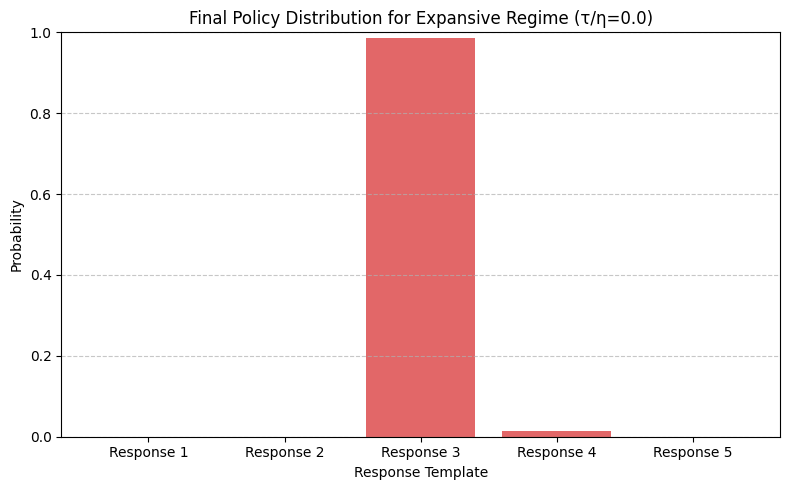

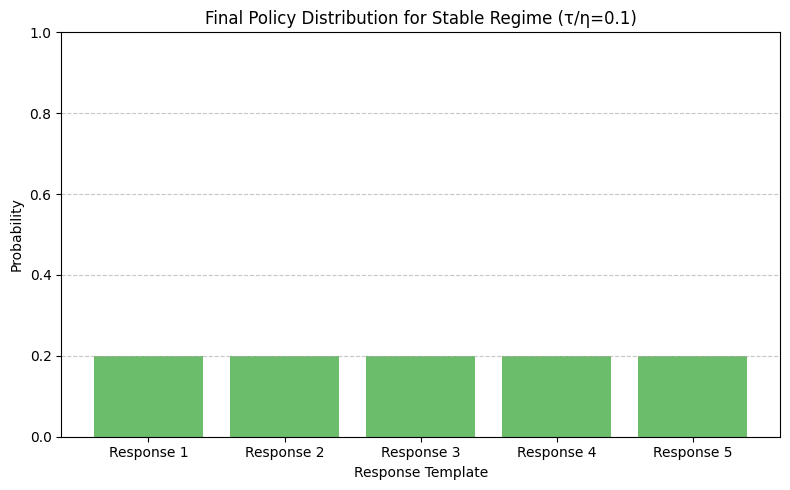

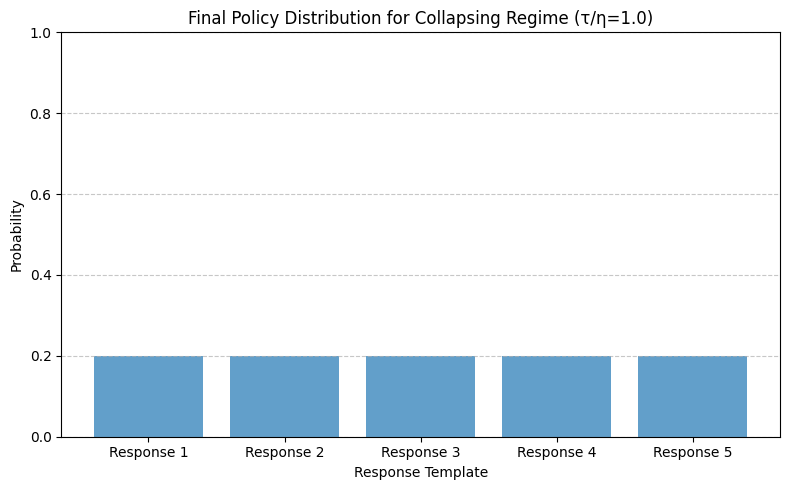

In [4]:
# Ensure the experiment has been run and results are available globally
try:
    # Plotting final policy distributions
    for name, (E, H, color, tau, final_p) in results.items():
        fig, ax = plt.subplots(figsize=(8, 5))
        response_labels = [f"Response {i+1}" for i in range(K)]
        ax.bar(response_labels, final_p, color=color, alpha=0.7)
        ax.set_title(f'Final Policy Distribution for {name} Regime (τ/η={tau/ETA:.1f})')
        ax.set_xlabel('Response Template')
        ax.set_ylabel('Probability')
        ax.set_ylim(0, 1) # Probabilities are between 0 and 1
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
except NameError:
    print("Error: 'results' is not defined. Please ensure you have modified the experiment cell to return 'results' and executed it.")

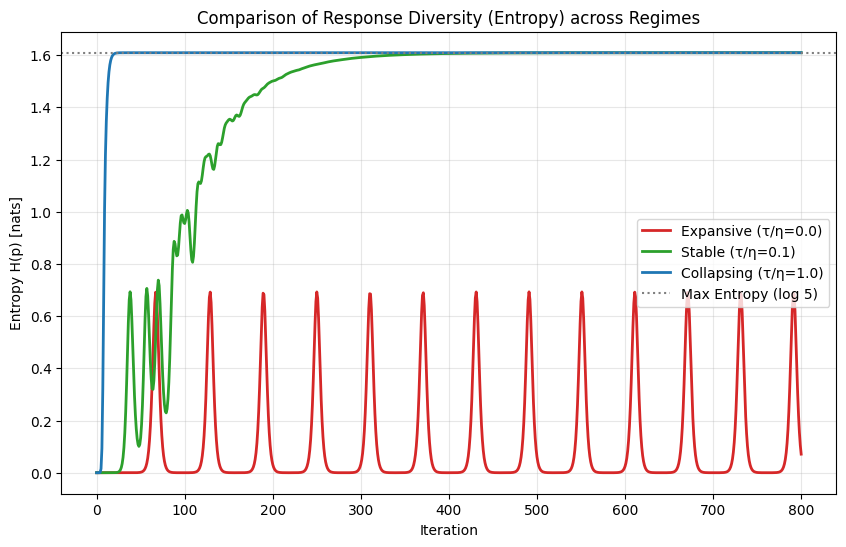

In [5]:
# Compare Entropy (Diversity) across all three regimes
plt.figure(figsize=(10, 6))
for name, (E, H, color, tau, _) in results.items():
    plt.plot(H, label=f"{name} (τ/η={tau/ETA:.1f})", color=color, lw=2)

plt.axhline(np.log(K), ls=":", color="gray", label=f"Max Entropy (log {K})")
plt.title("Comparison of Response Diversity (Entropy) across Regimes")
plt.xlabel("Iteration")
plt.ylabel("Entropy H(p) [nats]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()